# Fitting Galaxy Spectra

Photometry measures the *total light* in a few broad bands.
Spectroscopy resolves *individual features* — absorption lines,
emission lines, and continuum breaks — that carry far more
diagnostic power.

**Why spectroscopy matters:**

| Feature | Wavelength | What it constrains |
|---------|------------|-------------------|
| 4000 \AA\ break (D4000) | ~4000 \AA | Age + metallicity |
| Balmer series (H$\beta$, H$\gamma$, H$\delta$) | 4100--4860 \AA | Recent SFH (last ~1 Gyr) |
| H$\alpha$ | 6563 \AA | Current SFR, dust |
| [O III] $\lambda$5007 | 5007 \AA | Ionization state, AGN vs SF |
| Mg b, Fe lines | 5170--5270 \AA | Metallicity, [$\alpha$/Fe] |

Spectroscopy resolves the **age--dust--metallicity degeneracy** that
plagues broadband photometry.  This notebook shows how to generate
mock spectra, fit them with `diffsed`, diagnose the fit quality, and
compare the information content of photometry vs spectroscopy.

> **Prerequisites:** NB02 (forward model), NB03 (inference methods).

In [1]:
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

import numpy as np
import matplotlib.pyplot as plt

import sys; sys.path.insert(0, ".")
from _plot_style import setup_style, COLORS, SDSS_WAVE_EFF, safe_corner
setup_style()

from diffsed import (
    Model, ParamSpec, Uniform, Fixed, Fitter,
    load_ssp_data, load_filter_set,
)

# Reproducibility
key = jax.random.PRNGKey(707)

# Load SSP data and SDSS filters (for later photometric comparison)
ssp_data = load_ssp_data("../data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
filters = load_filter_set(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"])

## Generating Mock Spectra

A spectroscopic observation is a flux density measured on a
**wavelength grid** $\lambda_1, \dots, \lambda_{N_{\rm pix}}$ in the
*observed frame*.  The forward model predicts a rest-frame spectrum,
redshifts it, and resamples onto the observed grid.

Key choices:

- **Wavelength range:** determined by the spectrograph (e.g.\ SDSS
  covers 3800--9200 \AA).
- **Pixel count / resolution:** more pixels $\to$ more information,
  but also more noise per pixel.
- **Noise model:** typically $\sigma(\lambda) \propto f(\lambda) /
  \mathrm{SNR}$ (signal-dependent), so faint continuum regions are
  noisier in absolute terms.

We use `data_type="spectroscopy"` to tell the `Fitter` that the data
vector is a spectrum (not photometric fluxes).

W0315 10:51:28.074670 4814985 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


Wavelength range: 3800 -- 9200 A
N_pix = 500, SNR = 30.0
D = 9 physical params + 128 GP latents


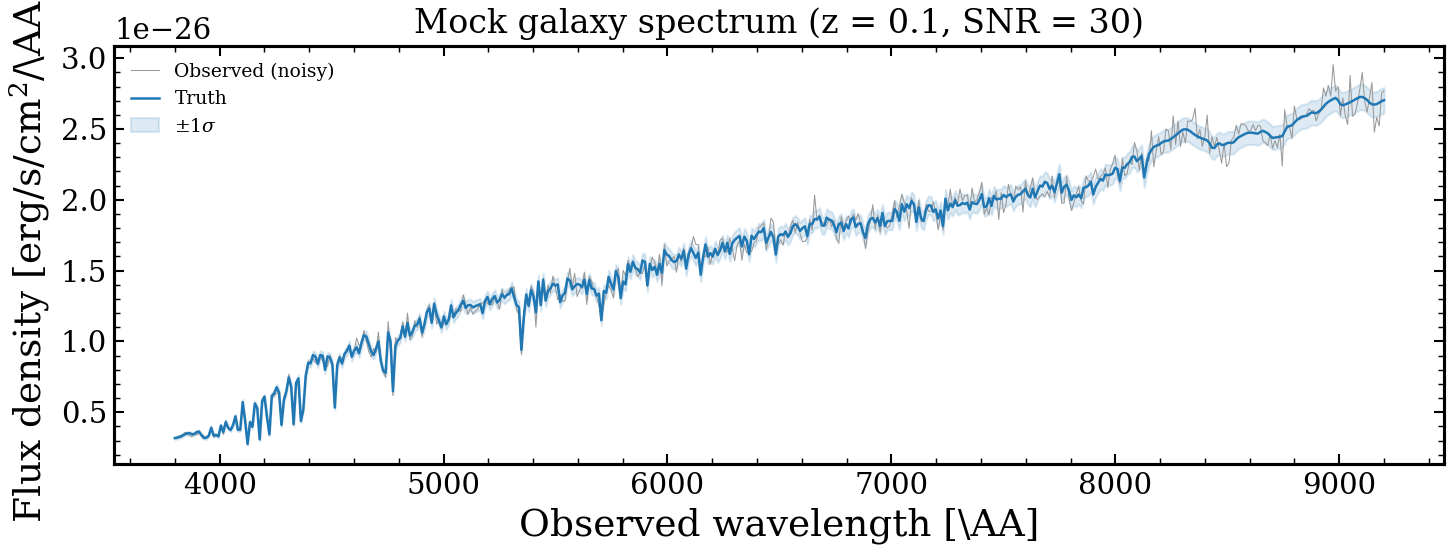

In [2]:
# Define a stochastic model for spectroscopic fitting
spec = ParamSpec(
    sfh_alpha=Uniform(0.5, 3.0),
    sfh_beta=Uniform(0.5, 3.0),
    sfh_tau_peak_gyr=Uniform(0.5, 13.0),
    sfh_peak_sfr=Uniform(0.1, 100.0),
    psd_sigma=Uniform(0.1, 4.0),
    psd_tau_myr=Uniform(1.0, 300.0),
    met_logzsol=Uniform(-2.0, 0.5),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 2.0),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    stochastic=True,
    n_grid=128,
)
model = Model(spec, ssp_data, filters=filters)

# Ground truth — use spec.sample() to include psd_xi for stochastic model
key, subkey = jax.random.split(key)
true_params = spec.sample(subkey)

# Observed-frame wavelength grid (SDSS-like coverage)
wave_obs = jnp.linspace(3800.0, 9200.0, 500)  # 500 pixels, ~10.8 A/pix

# Generate mock spectrum at SNR = 30
key, subkey = jax.random.split(key)
spec_true = model.predict_spectrum(true_params, wave_obs)
snr = 30.0
noise = spec_true / snr
spec_obs = spec_true + noise * jax.random.normal(subkey, spec_true.shape)

print(f"Wavelength range: {float(wave_obs[0]):.0f} -- {float(wave_obs[-1]):.0f} A")
print(f"N_pix = {len(wave_obs)}, SNR = {snr}")
print(f"D = {spec.n_free} physical params + 128 GP latents")

# Plot the mock spectrum
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(wave_obs, spec_obs, "0.6", lw=0.5, label="Observed (noisy)")
ax.plot(wave_obs, spec_true, "C0-", lw=1.2, label="Truth")
ax.fill_between(np.array(wave_obs),
                np.array(spec_true - noise),
                np.array(spec_true + noise),
                color="C0", alpha=0.15, label=r"$\pm 1\sigma$")
ax.set_xlabel(r"Observed wavelength [\AA]")
ax.set_ylabel(r"Flux density [erg/s/cm$^2$/\AA]")
ax.set_title(f"Mock galaxy spectrum (z = 0.1, SNR = {snr:.0f})")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

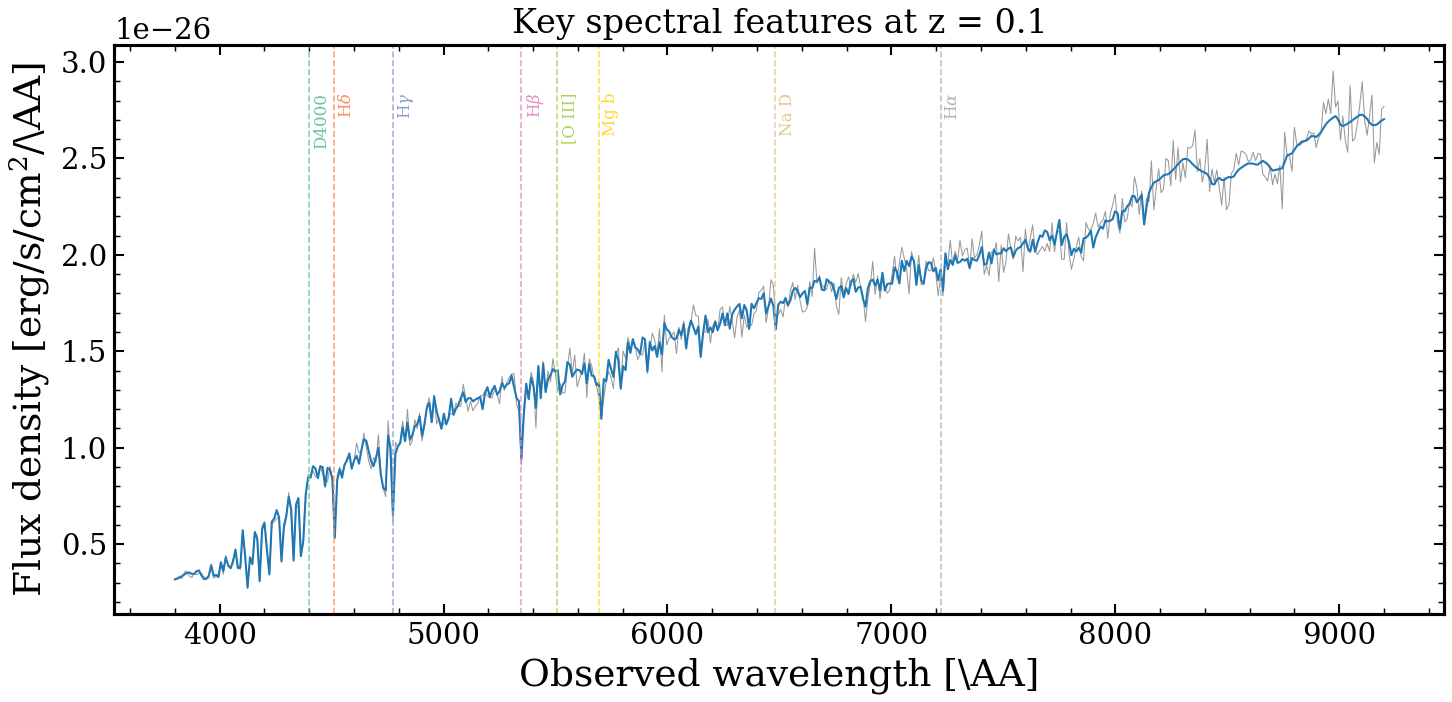

What each feature constrains:
  D4000 break  -> stellar age + metallicity
  Balmer series -> recent SFH (last ~1 Gyr)
  H-alpha      -> current SFR + dust attenuation
  [O III]      -> ionization state (AGN vs star-forming)
  Mg b, Na D   -> metallicity, alpha-element abundance


In [3]:
# Annotate key spectral features in the observed frame
z_true = 0.1  # redshift

# Rest-frame feature wavelengths (Angstrom)
features = {
    r"D4000": 4000.0,
    r"H$\delta$": 4102.0,
    r"H$\gamma$": 4340.0,
    r"H$\beta$": 4861.0,
    r"[O III]": 5007.0,
    r"Mg b": 5175.0,
    r"Na D": 5893.0,
    r"H$\alpha$": 6563.0,
}

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(wave_obs, spec_obs, "0.6", lw=0.5)
ax.plot(wave_obs, spec_true, "C0-", lw=1.0)

colors_feat = plt.cm.Set2(np.linspace(0, 1, len(features)))
for (name, lam_rest), color in zip(features.items(), colors_feat):
    lam_obs = lam_rest * (1.0 + z_true)
    if float(wave_obs[0]) <= lam_obs <= float(wave_obs[-1]):
        ax.axvline(lam_obs, color=color, ls="--", lw=0.8, alpha=0.8)
        ax.text(lam_obs + 15, ax.get_ylim()[1] * 0.92, name,
                fontsize=8, color=color, rotation=90, va="top")

ax.set_xlabel(r"Observed wavelength [\AA]")
ax.set_ylabel(r"Flux density [erg/s/cm$^2$/\AA]")
ax.set_title("Key spectral features at z = 0.1")
plt.tight_layout()
plt.show()

print("What each feature constrains:")
print("  D4000 break  -> stellar age + metallicity")
print("  Balmer series -> recent SFH (last ~1 Gyr)")
print("  H-alpha      -> current SFR + dust attenuation")
print("  [O III]      -> ionization state (AGN vs star-forming)")
print("  Mg b, Na D   -> metallicity, alpha-element abundance")

## Fitting a Spectrum

The workflow is the same as photometric fitting, but we pass
`data_type="spectroscopy"` and provide the observed wavelength grid:

```python
model._wave_obs = wave_obs
fitter = Fitter(model, spec_obs, noise,
                data_type="spectroscopy")
```

The likelihood becomes $\chi^2 = \sum_{i=1}^{N_{\rm pix}}
(d_i - f_i)^2 / \sigma_i^2$ summed over all spectral pixels
instead of photometric bands.  More data points $\to$ tighter
constraints $\to$ better-determined SFH.

We use **MAP initialization** followed by **Ray Tracing** for the
full posterior.

  Step     0/1500: loss = 137988.1703


  Step   200/1500: loss = 1034.1248


  Step   400/1500: loss = 779.2387


  Step   600/1500: loss = 769.9363


  Step   800/1500: loss = 760.8092


  Step  1000/1500: loss = 752.5858


  Step  1200/1500: loss = 745.6502


  Step  1400/1500: loss = 740.0912
  Step  1499/1500: loss = 737.8198
  MAP (ADAM) complete in 3.0s, 1500 steps


MAP: 3.0s, final loss = 737.82
Ray Tracing: 137 params, 100 burn-in + 300 samples, 10 leapfrog/step, step_size=0.0100


  Ray Tracing complete in 0.5s. Acceptance: 0.0% (overall), 0.0% (post burn-in). Samples: 300
Ray Tracing: 0.5s, acceptance = 0.00%


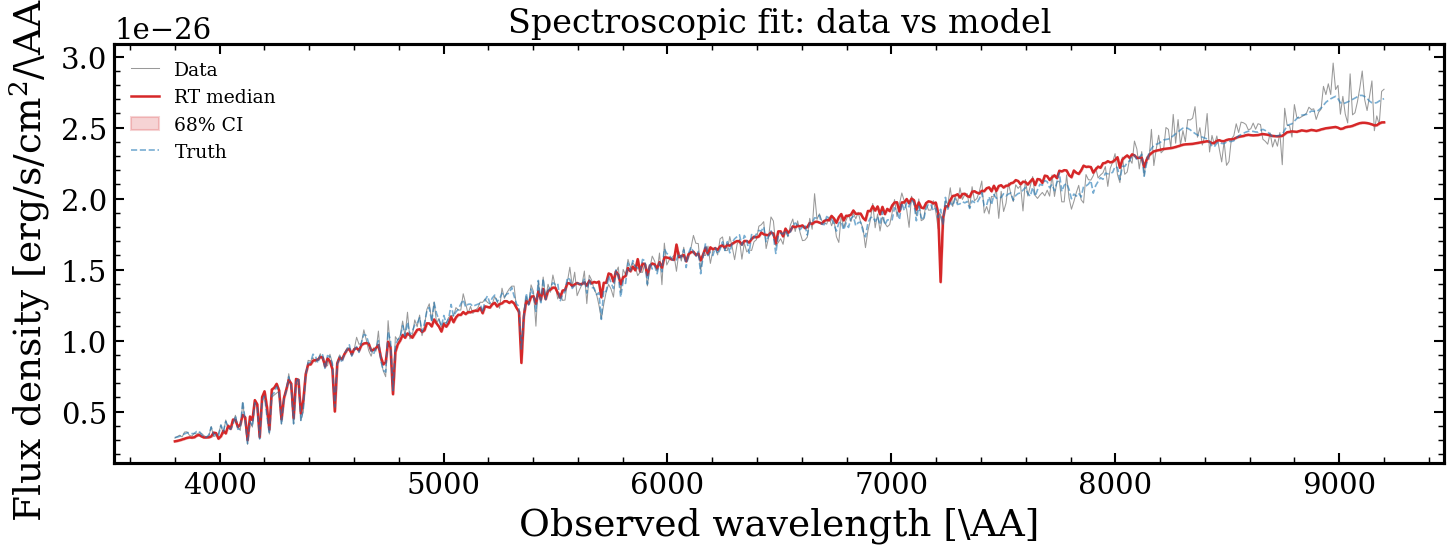

In [4]:
# Spectroscopic fit: MAP -> Ray Tracing
model._wave_obs = wave_obs
fitter = Fitter(model, spec_obs, noise,
                data_type="spectroscopy")

# MAP initialization
key, subkey = jax.random.split(key)
result_map = fitter.run("map", n_steps=1500, key=subkey)
print(f"MAP: {result_map.wall_time_s:.1f}s, "
      f"final loss = {float(result_map.loss_history[-1]):.2f}")

# Ray Tracing posterior (step_size=0.01 for high-D stochastic model)
key, subkey = jax.random.split(key)
result_rt = fitter.run(
    "raytrace",
    init_from=result_map,
    n_burnin=100,
    n_steps=300,
    step_size=0.01,
    key=subkey,
)
accept = result_rt.diagnostics.get("accept_rate_post_burnin", 0)
print(f"Ray Tracing: {result_rt.wall_time_s:.1f}s, "
      f"acceptance = {accept:.2%}")

# Overlay best-fit spectrum on data
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(wave_obs, spec_obs, "0.6", lw=0.5, label="Data")

# Posterior median spectrum (draw a few samples)
spec_draws = []
n_draws = min(50, len(list(result_rt.samples.values())[0]))
for k_idx in range(n_draws):
    draw = {name: (arr[k_idx] if name == 'psd_xi' else float(arr[k_idx])) for name, arr in result_rt.samples.items()}
    spec_draws.append(np.array(model.predict_spectrum(draw, wave_obs)))
spec_draws = np.array(spec_draws)
spec_median = np.median(spec_draws, axis=0)
spec_lo, spec_hi = np.percentile(spec_draws, [16, 84], axis=0)

ax.plot(wave_obs, spec_median, "C3-", lw=1.2, label="RT median")
ax.fill_between(np.array(wave_obs), spec_lo, spec_hi,
                color="C3", alpha=0.2, label="68% CI")
ax.plot(wave_obs, spec_true, "C0--", lw=0.8, alpha=0.6, label="Truth")
ax.set_xlabel(r"Observed wavelength [\AA]")
ax.set_ylabel(r"Flux density [erg/s/cm$^2$/\AA]")
ax.set_title("Spectroscopic fit: data vs model")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Corner plot skipped: Contour levels must be increasing


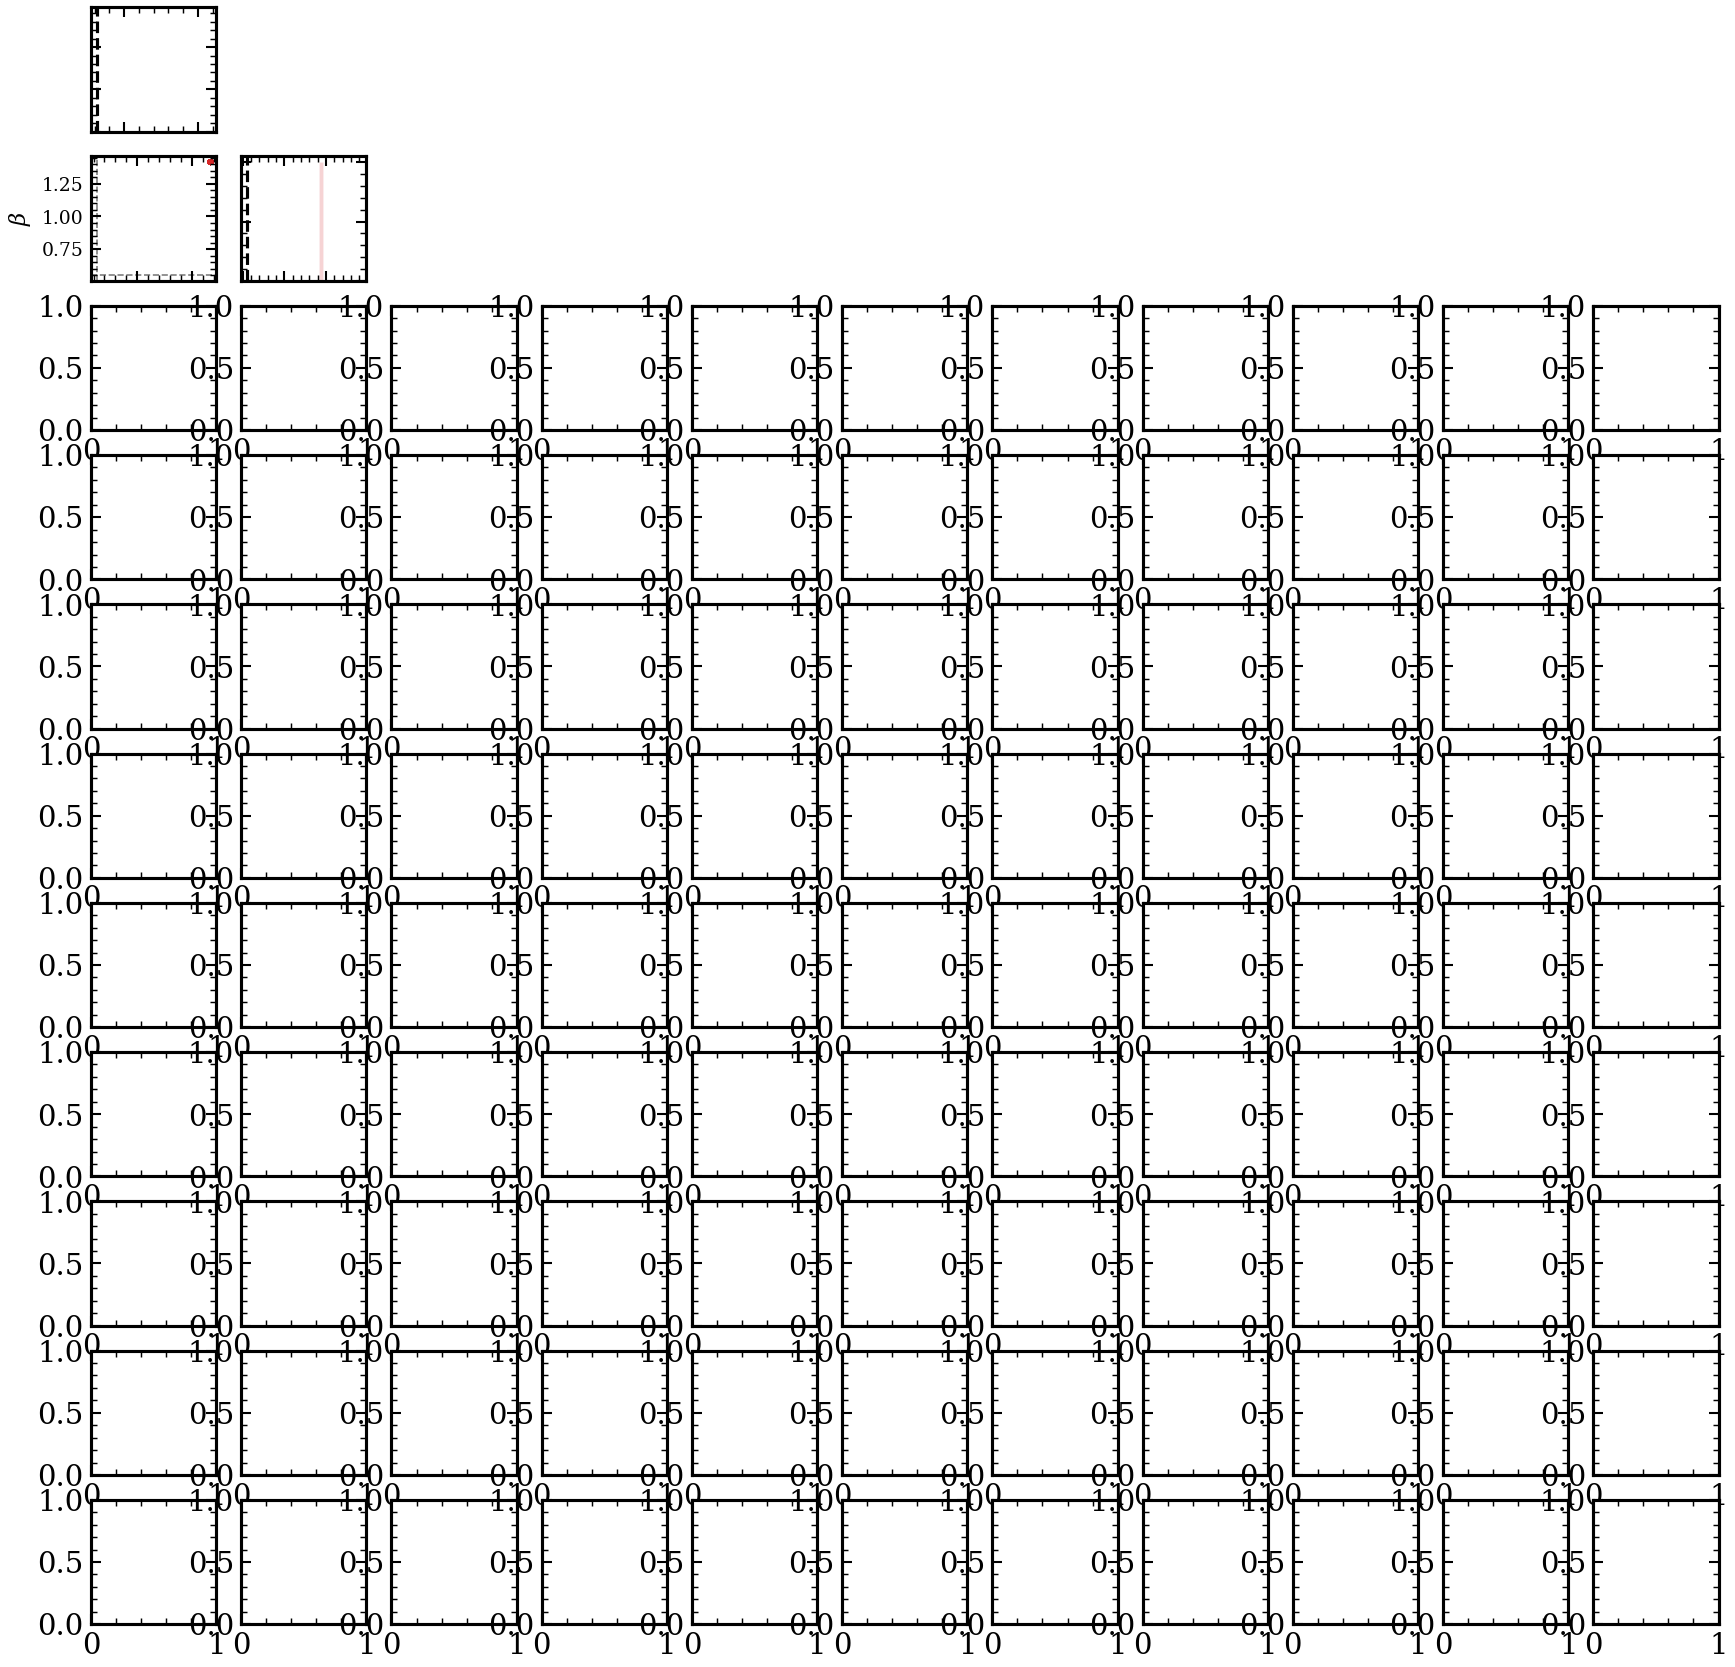

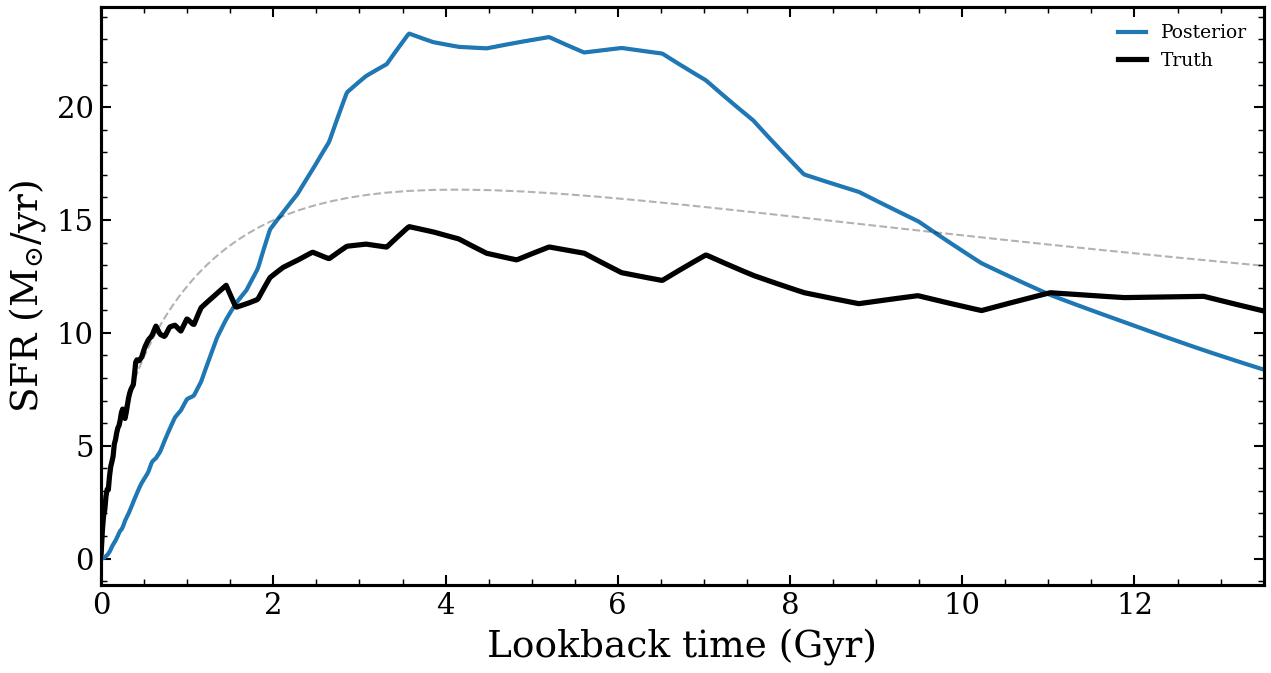

In [5]:
# Corner plot + SFH recovery
phys_params = ["sfh_alpha", "sfh_beta", "sfh_tau_peak_gyr", "sfh_peak_sfr",
               "psd_sigma", "psd_tau_myr", "met_logzsol",
               "dust_tau_bc", "dust_tau_diff"]

fig = safe_corner(result_rt,
    params=phys_params,
    truths=true_params,
    color="C3",
    label="Spectroscopy (RT)",
)
if fig is not None:
    fig.suptitle("Spectroscopic posterior — physical parameters", fontsize=14, y=1.02)
plt.show()

# SFH recovery
model.plot_sfh_posterior(result_rt, true_params=true_params)
plt.show()

## Residual Analysis

A good fit is not just about recovering the right parameters —
you must verify that the **residuals** $(d_i - f_i) / \sigma_i$
are consistent with noise.

**What to look for:**

- **$\chi^2 / N_{\rm dof}$** should be close to 1.
- **Flat residuals:** no systematic trends with wavelength.
- **Feature-by-feature:** check that individual absorption/emission
  lines are well-fit (residuals should not spike at known features).
- **Correlated residuals:** runs of positive or negative residuals
  indicate model mismatch (e.g.\ wrong continuum shape, missing
  emission lines).

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_92365/617374787.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


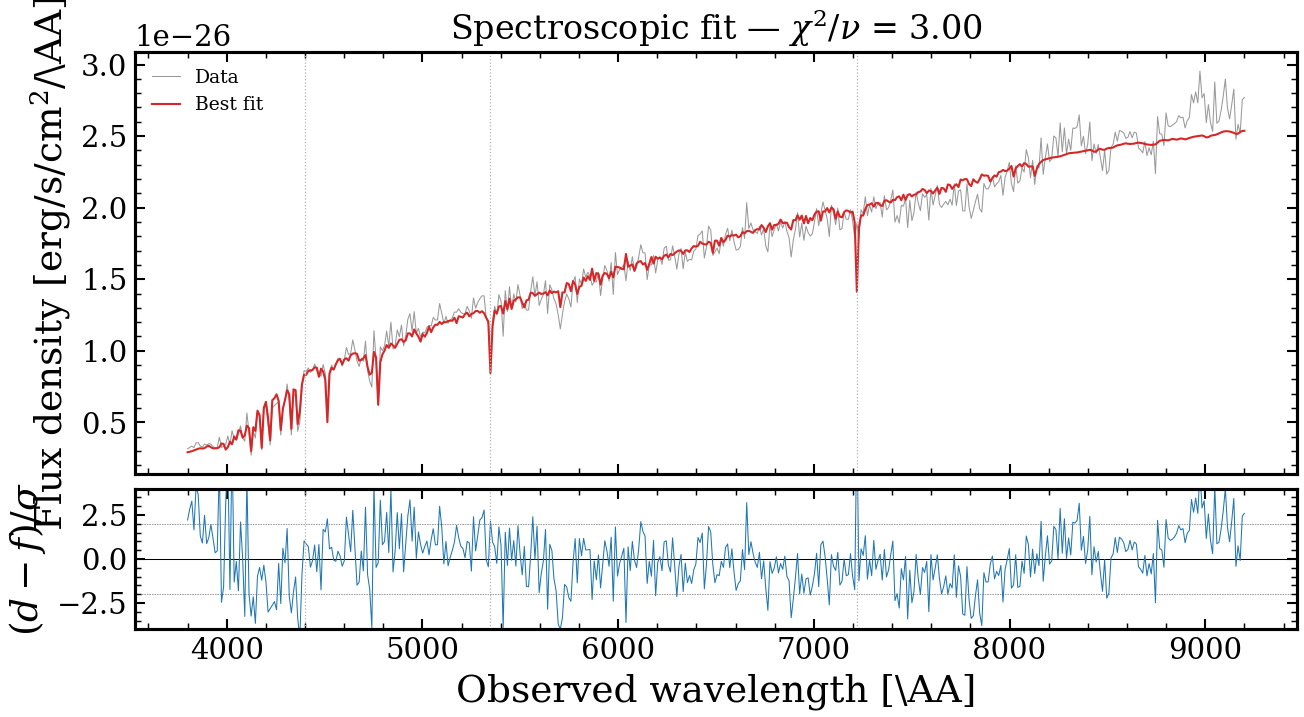

chi2 = 1472.0
N_dof = 491
chi2 / N_dof = 2.998
Mean |residual| = 1.319 (expect ~0.80)
Fraction |residual| > 2: 22.4% (expect ~5%)


In [6]:
# Residual analysis
spec_bestfit = np.median(spec_draws, axis=0)
residuals = (np.array(spec_obs) - spec_bestfit) / np.array(noise)
chi2 = np.sum(residuals**2)
n_dof = len(wave_obs) - spec.n_free
chi2_per_dof = chi2 / n_dof

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})

# Top: spectrum + fit
axes[0].plot(wave_obs, spec_obs, "0.6", lw=0.5, label="Data")
axes[0].plot(wave_obs, spec_bestfit, "C3-", lw=1.0, label="Best fit")
axes[0].set_ylabel(r"Flux density [erg/s/cm$^2$/\AA]")
axes[0].legend(fontsize=9)
axes[0].set_title(f"Spectroscopic fit — $\\chi^2/\\nu$ = {chi2_per_dof:.2f}")

# Bottom: normalized residuals
axes[1].axhline(0, color="k", lw=0.5)
axes[1].axhline(2, color="k", lw=0.3, ls=":")
axes[1].axhline(-2, color="k", lw=0.3, ls=":")
axes[1].plot(wave_obs, residuals, "C0-", lw=0.5)
axes[1].set_ylabel(r"$(d - f) / \sigma$")
axes[1].set_xlabel(r"Observed wavelength [\AA]")
axes[1].set_ylim(-4, 4)

# Highlight spectral features in residuals
z_true = 0.1
for name, lam_rest in [("D4000", 4000.0), (r"H$\beta$", 4861.0),
                        (r"H$\alpha$", 6563.0)]:
    lam_obs_feat = lam_rest * (1 + z_true)
    for ax in axes:
        ax.axvline(lam_obs_feat, color="0.7", ls=":", lw=0.6)

plt.tight_layout()
plt.show()

print(f"chi2 = {chi2:.1f}")
print(f"N_dof = {n_dof}")
print(f"chi2 / N_dof = {chi2_per_dof:.3f}")
print(f"Mean |residual| = {np.mean(np.abs(residuals)):.3f} (expect ~0.80)")
print(f"Fraction |residual| > 2: {np.mean(np.abs(residuals) > 2):.1%} (expect ~5%)")

## Signal-to-Noise Ratio

How does spectral SNR affect parameter recovery?  Lower SNR means
wider posteriors and more degenerate solutions.  Higher SNR drives
tighter constraints, but with diminishing returns once systematics
dominate.

We fit the **same galaxy** at SNR = 10, 30, and 100, using MAP + RT
for each, and compare the posterior widths.

  Step     0/1500: loss = 17162.2470


  Step   200/1500: loss = 307.6489


  Step   400/1500: loss = 297.4497


  Step   600/1500: loss = 292.3548


  Step   800/1500: loss = 286.2354


...

  Step   800/1500: loss = 4914.3166


  Step  1000/1500: loss = 4213.8085


  Step  1200/1500: loss = 3476.5041


  Step  1400/1500: loss = 2486.4243
  Step  1499/1500: loss = 2151.2314
  MAP (ADAM) complete in 3.0s, 1500 steps
Ray Tracing: 137 params, 100 burn-in + 300 samples, 10 leapfrog/step, step_size=0.0100


  Ray Tracing complete in 0.6s. Acceptance: 0.0% (overall), 0.0% (post burn-in). Samples: 300
SNR=100: RT 0.6s, accept=0.00%


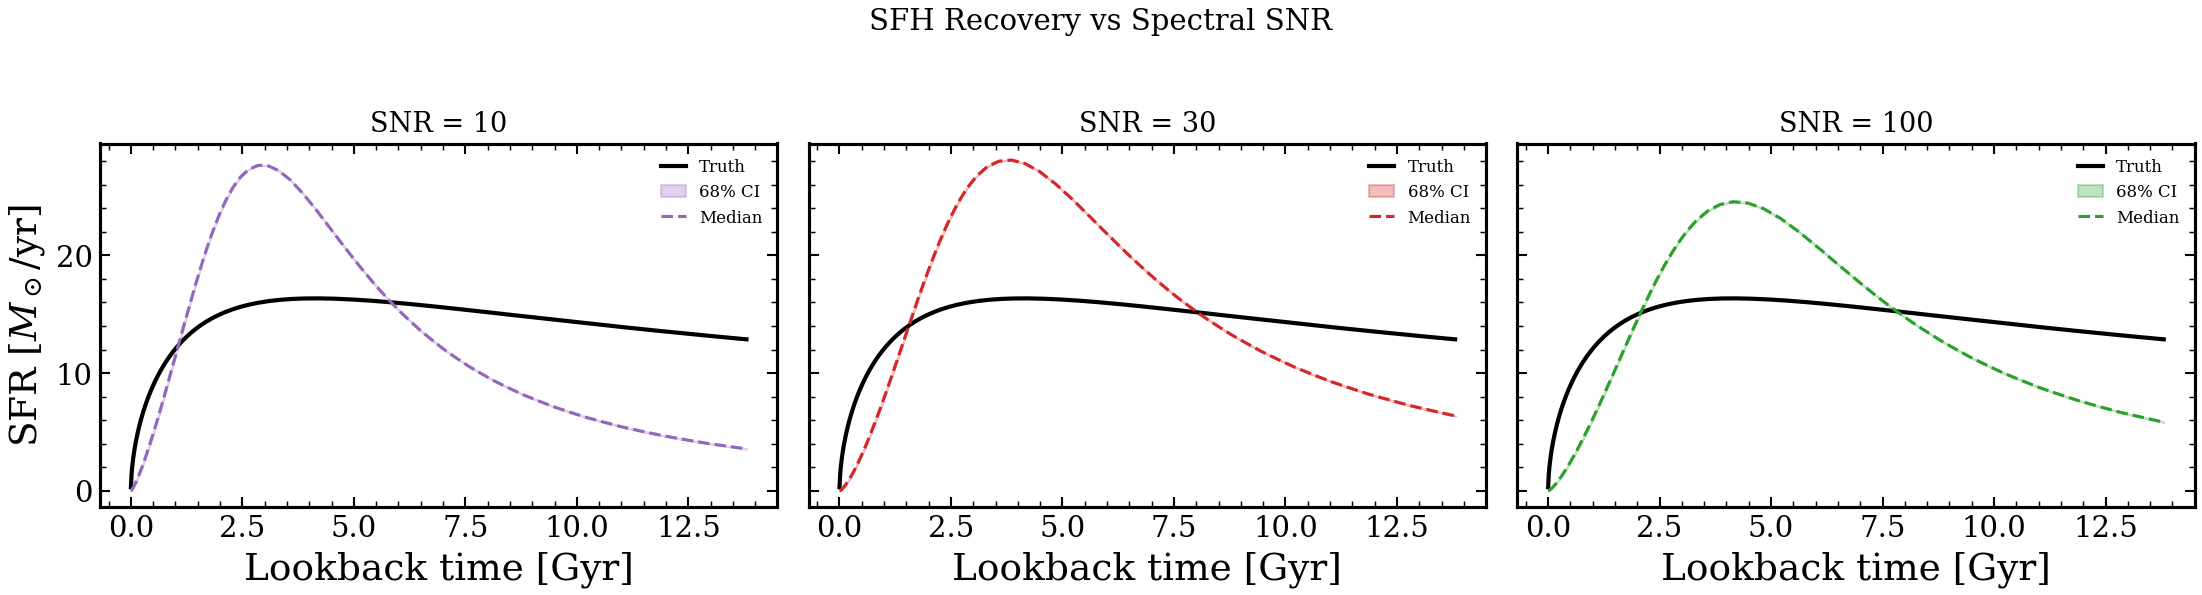

In [7]:
# Fit at three SNR values
snr_values = [10, 30, 100]
results_snr = {}

for snr_val in snr_values:
    noise_snr = spec_true / snr_val
    key, subkey = jax.random.split(key)
    spec_obs_snr = spec_true + noise_snr * jax.random.normal(subkey, spec_true.shape)

    model._wave_obs = wave_obs
    fitter_snr = Fitter(model, spec_obs_snr, noise_snr,
                        data_type="spectroscopy")

    key, subkey = jax.random.split(key)
    map_snr = fitter_snr.run("map", n_steps=1500, key=subkey)

    key, subkey = jax.random.split(key)
    rt_snr = fitter_snr.run(
        "raytrace",
        init_from=map_snr,
        n_burnin=100,
        n_steps=300,
        step_size=0.01,
        key=subkey,
    )
    results_snr[snr_val] = rt_snr
    accept = rt_snr.diagnostics.get("accept_rate_post_burnin", 0)
    print(f"SNR={snr_val}: RT {rt_snr.wall_time_s:.1f}s, accept={accept:.2%}")

# 1x3 SFH recovery panels
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
colors_snr = ["C4", "C3", "C2"]
sfh_truth = model.predict_sfh(true_params)

for ax, snr_val, col in zip(axes, snr_values, colors_snr):
    res = results_snr[snr_val]
    ax.plot(sfh_truth["t_gyr"], sfh_truth["sfr_mean"], "k-", lw=2, label="Truth")

    sfr_draws = []
    n_d = min(100, len(list(res.samples.values())[0]))
    for k_idx in range(n_d):
        draw = {name: (arr[k_idx] if name == 'psd_xi' else float(arr[k_idx])) for name, arr in res.samples.items()}
        sfh_draw = model.predict_sfh(draw)
        sfr_draws.append(sfh_draw["sfr_mean"])
    sfr_draws = np.array(sfr_draws)
    lo, hi = np.percentile(sfr_draws, [16, 84], axis=0)
    ax.fill_between(sfh_truth["t_gyr"], lo, hi, color=col, alpha=0.3, label="68% CI")
    ax.plot(sfh_truth["t_gyr"], np.median(sfr_draws, axis=0),
            color=col, ls="--", lw=1.5, label="Median")

    ax.set_xlabel("Lookback time [Gyr]")
    ax.set_title(f"SNR = {snr_val}", fontsize=13)
    ax.legend(fontsize=8, loc="upper right")

axes[0].set_ylabel(r"SFR [$M_\odot$/yr]")
fig.suptitle("SFH Recovery vs Spectral SNR", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Photometry vs Spectroscopy: Head-to-Head

Same galaxy, same ground truth, same inference method (MAP + RT).
How much tighter are spectroscopic constraints compared to 5-band
SDSS photometry?

The comparison is not entirely fair — a spectrum with 500 pixels at
SNR = 30 carries $\sim$500 independent data points, while 5-band
photometry gives only 5.  But this *is* the real-world tradeoff:
spectra are expensive but informative.

  Step     0/1500: loss = 755.0821
  Step   200/1500: loss = 3.2399
  Step   400/1500: loss = 2.3300
  Step   600/1500: loss = 1.9117
  Step   800/1500: loss = 1.6891
  Step  1000/1500: loss = 1.5327
  Step  1200/1500: loss = 1.3948
  Step  1400/1500: loss = 1.2645
  Step  1499/1500: loss = 1.2032
  MAP (ADAM) complete in 0.3s, 1500 steps
Ray Tracing: 137 params, 100 burn-in + 300 samples, 10 leapfrog/step, step_size=0.0100


  Ray Tracing complete in 0.4s. Acceptance: 98.5% (overall), 98.5% (post burn-in). Samples: 300
Photometry RT: 0.4s


Corner plot skipped: Contour levels must be increasing


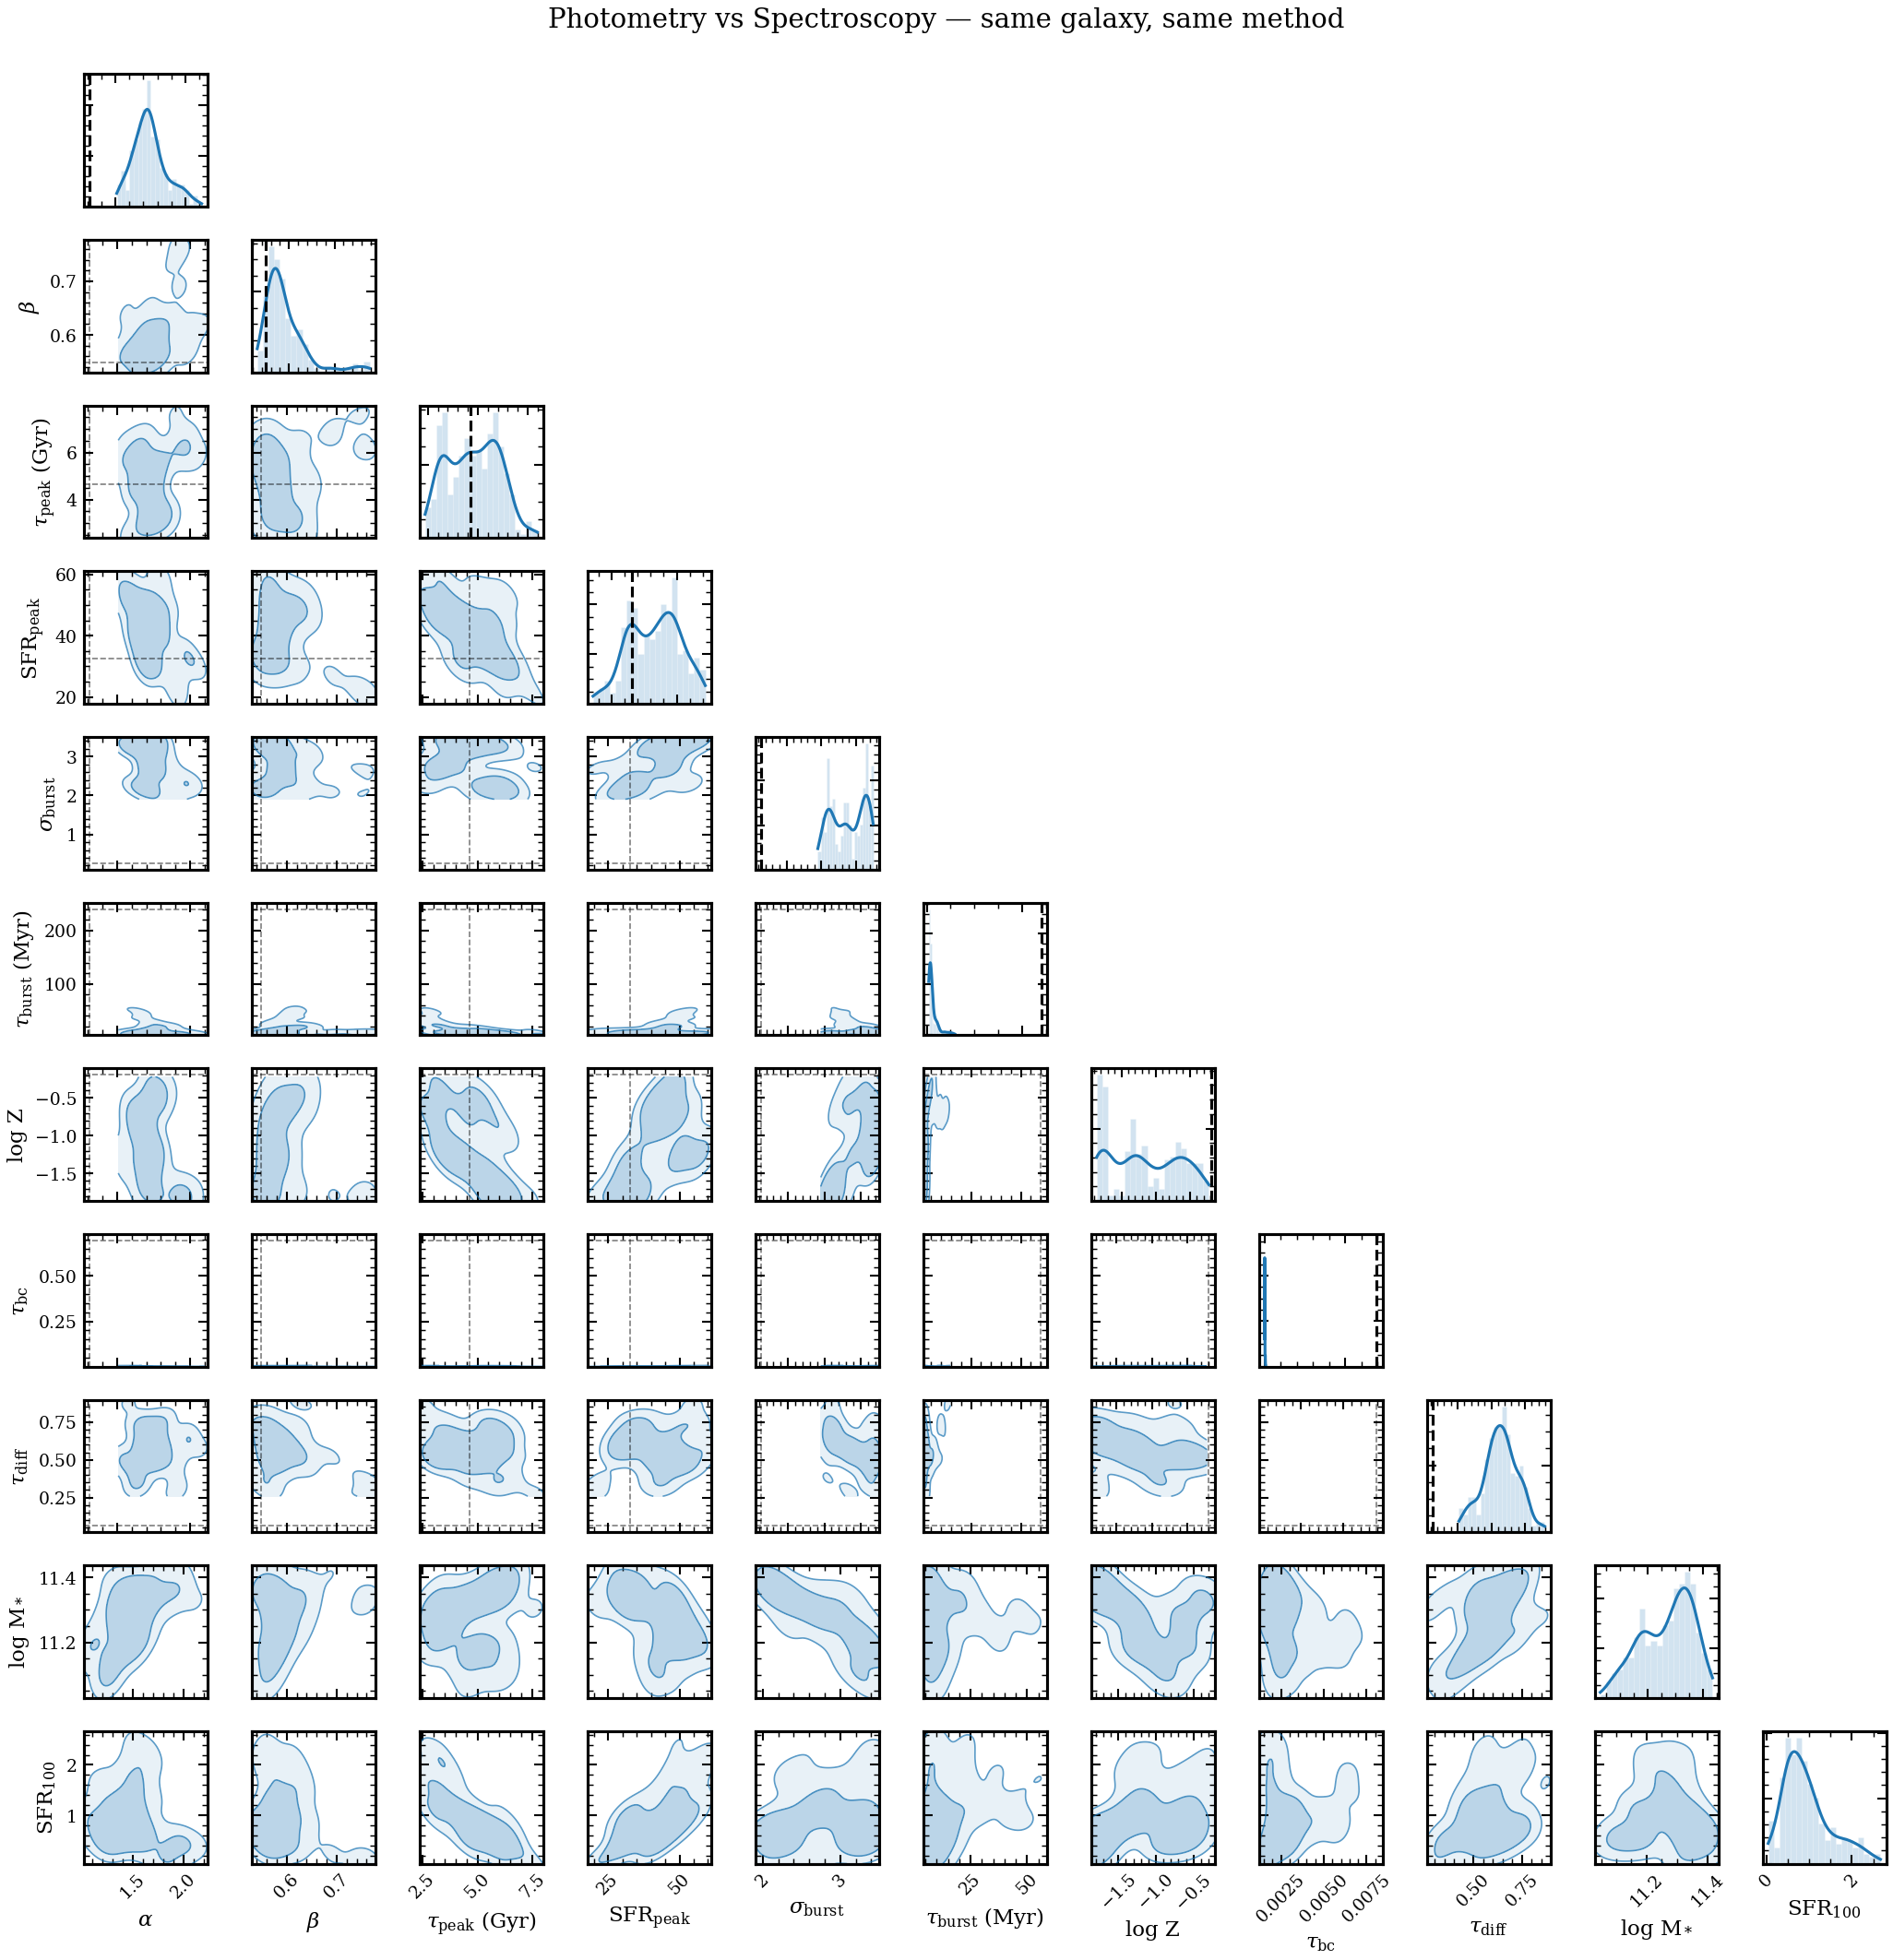

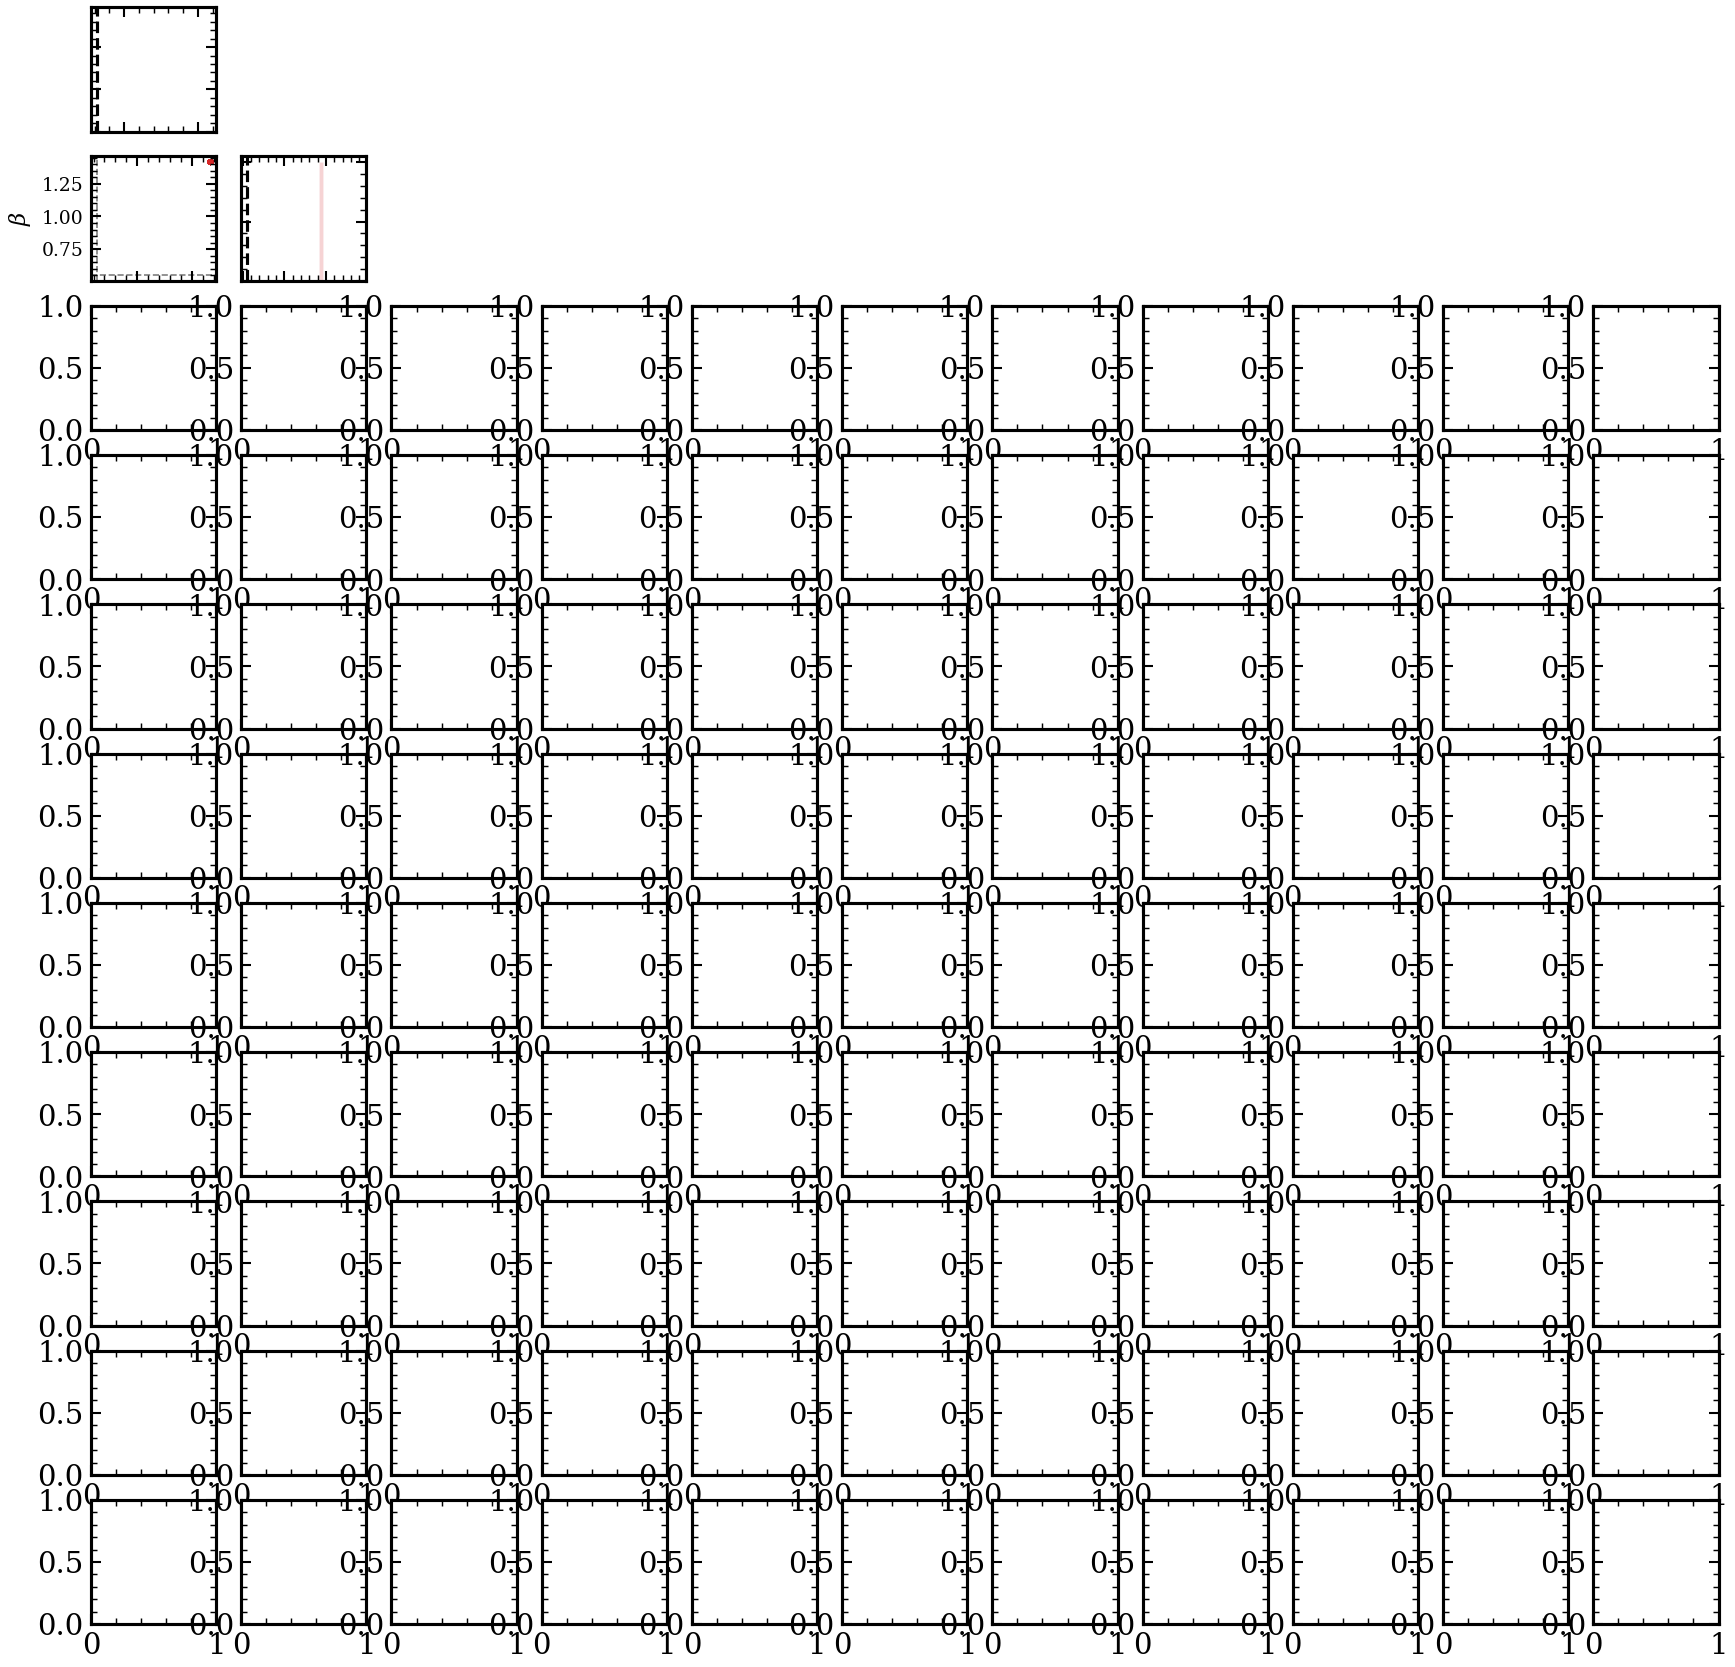


Posterior width comparison (68% CI):
Parameter                   Phot width   Spec width  Improvement
-----------------------------------------------------------------
sfh_alpha                        0.466        0.000         infx
sfh_beta                         0.066        0.000         infx
sfh_tau_peak_gyr                 2.859        0.000         infx
sfh_peak_sfr                    20.080        0.000         infx
psd_sigma                        1.142        0.000         infx
psd_tau_myr                     14.869        0.000         infx
met_logzsol                      1.216        0.000         infx
dust_tau_bc                      0.002        0.000         infx
dust_tau_diff                    0.251        0.000         infx


In [8]:
# Photometric fit for comparison
key, subkey = jax.random.split(key)
mock_phot = model.mock(true_params, snr=20.0, key=subkey)

fitter_phot = Fitter(model, mock_phot.flux_obs, mock_phot.noise,
                     data_type="photometry")

key, subkey = jax.random.split(key)
map_phot = fitter_phot.run("map", n_steps=1500, key=subkey)

key, subkey = jax.random.split(key)
rt_phot = fitter_phot.run(
    "raytrace",
    init_from=map_phot,
    n_burnin=100,
    n_steps=300,
    step_size=0.01,
    key=subkey,
)
print(f"Photometry RT: {rt_phot.wall_time_s:.1f}s")

# Overlay corner plots: photometry (blue) vs spectroscopy (red)
# Use the SNR=30 spectroscopic result from the main fit
fig = safe_corner(rt_phot,
    params=phys_params,
    truths=true_params,
    color="C0",
    label="Photometry (5-band)",
)
if fig is not None:
    safe_corner(result_rt,
        params=phys_params,
        truths=true_params,
        color="C3",
        label="Spectroscopy (500 pix)",
        fig=fig,
    )
    fig.suptitle("Photometry vs Spectroscopy — same galaxy, same method",
                 fontsize=14, y=1.02)
plt.show()

# Quantify constraint improvement
print("\nPosterior width comparison (68% CI):")
print(f"{'Parameter':<25} {'Phot width':>12} {'Spec width':>12} {'Improvement':>12}")
print("-" * 65)
for p in phys_params:
    phot_chain = np.array(rt_phot.samples[p])
    spec_chain = np.array(result_rt.samples[p])
    w_phot = np.percentile(phot_chain, 84) - np.percentile(phot_chain, 16)
    w_spec = np.percentile(spec_chain, 84) - np.percentile(spec_chain, 16)
    ratio = w_phot / w_spec if w_spec > 0 else np.inf
    print(f"{p:<25} {w_phot:>12.3f} {w_spec:>12.3f} {ratio:>11.1f}x")

## Spectroscopy at Different Redshifts

The observable wavelength range is fixed by the instrument, but the
**rest-frame** coverage shifts with redshift:
$\lambda_{\rm rest} = \lambda_{\rm obs} / (1 + z)$.

At higher redshift, rest-frame UV features enter the optical window
while rest-frame optical features shift to the NIR.  This determines
which physical properties can be constrained:

| Redshift | Survey | $\lambda_{\rm obs}$ range | Rest-frame coverage | Key features |
|----------|--------|--------------------------|--------------------|----|
| $z = 0.1$ | SDSS | 3800--9200 \AA | 3450--8360 \AA | D4000, Balmer, H$\alpha$ |
| $z = 1.0$ | DESI | 3600--9800 \AA | 1800--4900 \AA | UV slope, D4000, Balmer |
| $z = 6.0$ | JWST/NIRSpec | 6000--53000 \AA | 860--7570 \AA | Ly$\alpha$, UV, D4000 |

<>:41: SyntaxWarning: invalid escape sequence '\A'
<>:41: SyntaxWarning: invalid escape sequence '\A'
/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_92365/3355404949.py:41: SyntaxWarning: invalid escape sequence '\A'
  f"(rest: {rest_lo:.0f}--{rest_hi:.0f} \AA)",


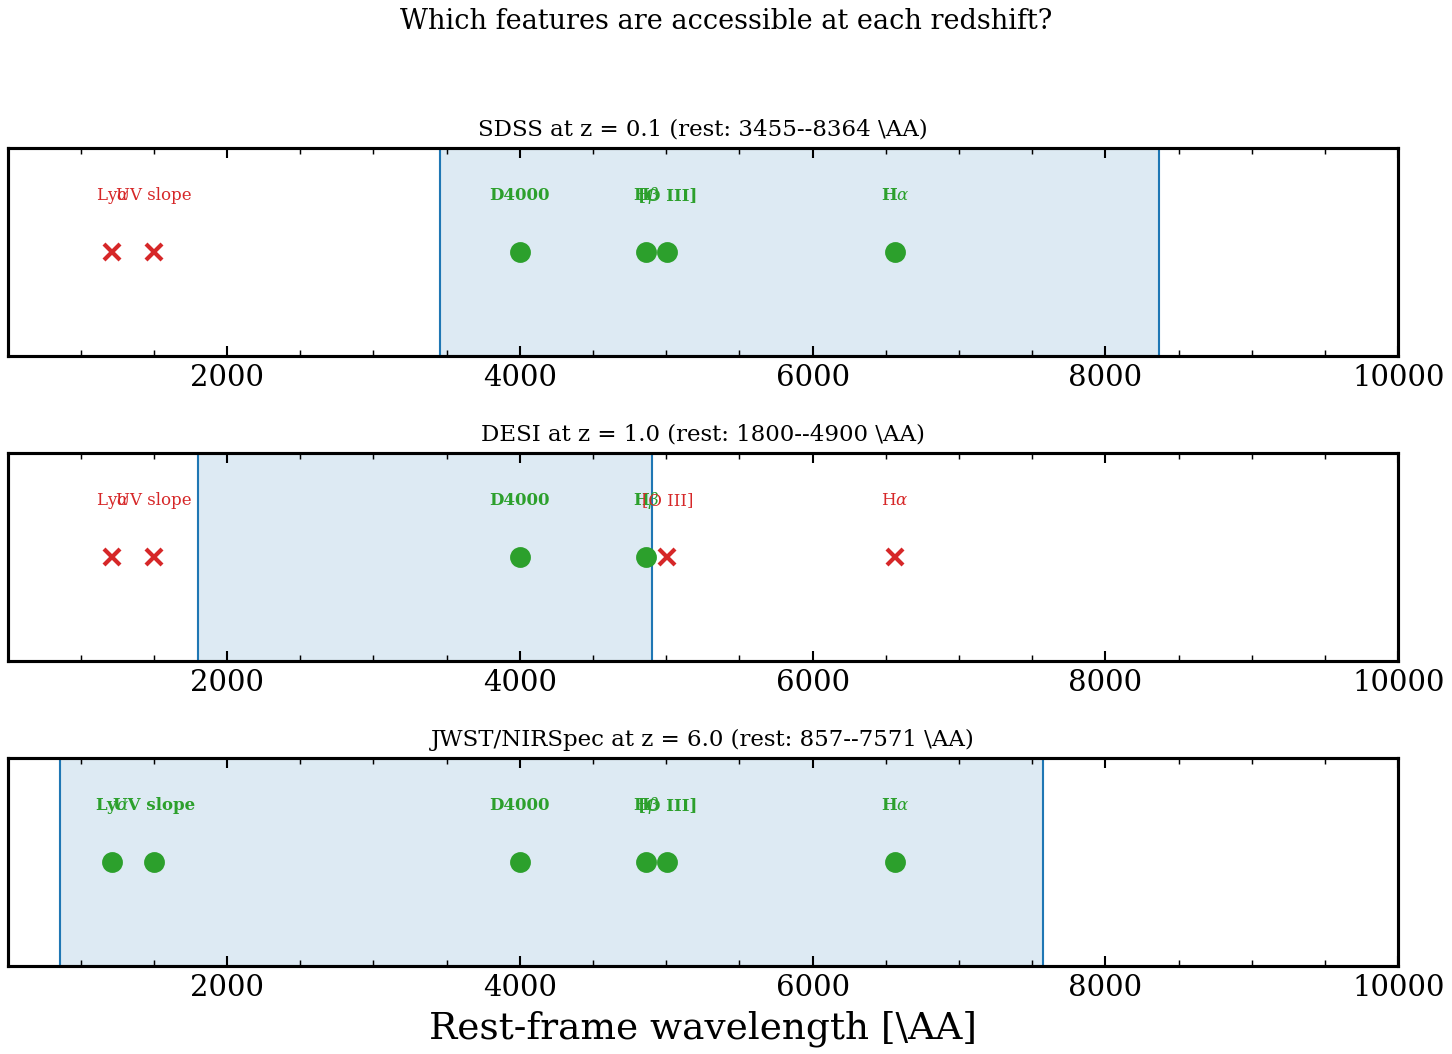

In [9]:
# Visualize spectral feature accessibility at different redshifts
redshifts = [0.1, 1.0, 6.0]
survey_names = ["SDSS", "DESI", "JWST/NIRSpec"]
obs_ranges = [(3800, 9200), (3600, 9800), (6000, 53000)]  # Angstrom

# Rest-frame features
rest_features = {
    r"Ly$\alpha$": 1216.0,
    "UV slope": 1500.0,
    "D4000": 4000.0,
    r"H$\beta$": 4861.0,
    r"[O III]": 5007.0,
    r"H$\alpha$": 6563.0,
}

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=False)

for ax, z, survey, (lam_lo, lam_hi) in zip(axes, redshifts, survey_names, obs_ranges):
    # Rest-frame range accessible
    rest_lo = lam_lo / (1 + z)
    rest_hi = lam_hi / (1 + z)

    # Draw accessible range
    ax.axvspan(rest_lo, rest_hi, color="C0", alpha=0.15)
    ax.axvline(rest_lo, color="C0", lw=1)
    ax.axvline(rest_hi, color="C0", lw=1)

    # Mark features
    for name, lam_rest in rest_features.items():
        in_range = rest_lo <= lam_rest <= rest_hi
        color = "C2" if in_range else "C3"
        marker = "o" if in_range else "x"
        ax.plot(lam_rest, 0.5, marker, color=color, ms=8, mew=2)
        ax.text(lam_rest, 0.75, name, fontsize=8, ha="center",
                color=color, fontweight="bold" if in_range else "normal")

    ax.set_xlim(500, 10000)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_title(f"{survey} at z = {z} "
                 f"(rest: {rest_lo:.0f}--{rest_hi:.0f} \AA)",
                 fontsize=11)

axes[-1].set_xlabel(r"Rest-frame wavelength [\AA]")
fig.suptitle("Which features are accessible at each redshift?",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Practical Guidance

### Survey Quick-Reference

| Survey | $\lambda_{\rm obs}$ [\AA] | $R$ | Key features at target $z$ | Best-constrained properties |
|--------|--------------------------|-----|---------------------------|---------------------------|
| SDSS | 3800--9200 | ~2000 | D4000, Balmer, H$\alpha$ ($z < 0.4$) | Age, metallicity, SFR, dust |
| DESI | 3600--9800 | 2000--5000 | D4000 ($z < 1.5$), UV slope ($z > 0.8$) | SFH shape, metallicity |
| JWST/NIRSpec | 6000--53000 | 100--2700 | Ly$\alpha$ to D4000 ($z \sim 4$--$8$) | UV slope, early SFH |
| VLT/MUSE | 4650--9300 | 1770--3590 | D4000, [O III] ($z < 0.9$) | Spatially resolved SFH |

### Fitting Checklist

1. **Always check residuals.** A good $\chi^2/\nu$ does not guarantee
   a correct model — look for systematic patterns at known features.
2. **Wavelength-dependent noise.** Real spectra have noise that varies
   with wavelength (sky lines, detector edges, atmospheric absorption).
   Always use a realistic noise vector.
3. **Calibration systematics.** Flux calibration errors introduce
   correlated residuals.  If you see broad wiggles in the residuals,
   consider a polynomial calibration correction.
4. **Emission lines.** The current `diffsed` forward model does not
   include nebular emission.  Mask strong emission lines ([O III],
   H$\alpha$, [N II]) or fit them separately.
5. **Resolution matching.** Convolve the model to the spectrograph's
   line-spread function before comparing.  Unresolved features lead
   to biased absorption-line measurements.
6. **MAP first, sample second.** Always initialize samplers (RT, geoVI)
   from a MAP solution.  Cold starts waste burn-in.

## Next Steps

- **NB06: Data and Information Content** — quantifying how much
  information each observation type provides.
- **NB08: PSD Physics** — the power spectral density that governs
  burstiness in the stochastic SFH.
- **NB09: Custom Models** — extending `diffsed` with your own
  forward model components.
- **NB03: Inference Methods** — deep dive into MAP, RT, geoVI,
  NUTS, and MGVI.